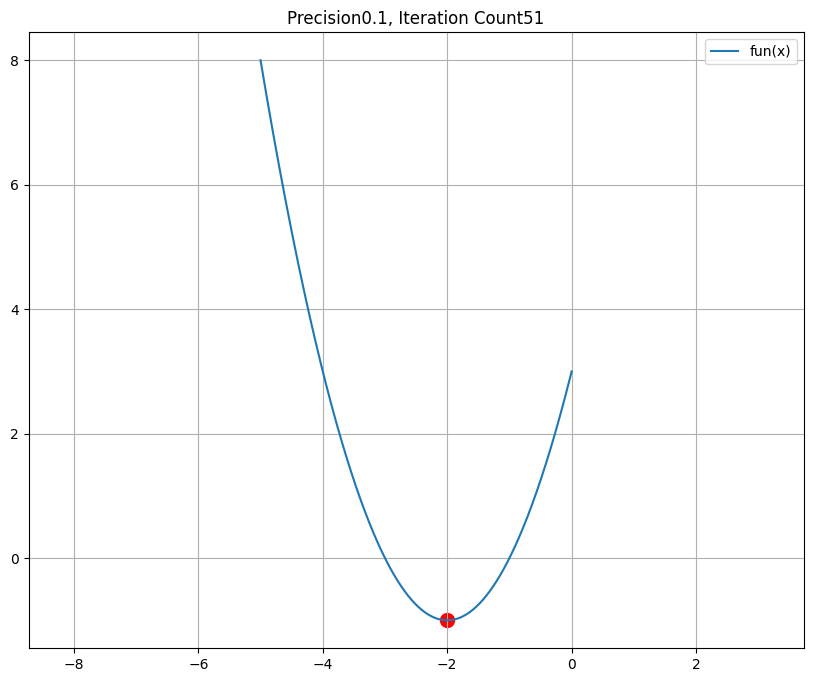

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

def fun(x):
    return (x+2)**2 - 1

def violent_search(fun_input, x_min, x_max, epsilon):
    """
    暴力搜索方法
    fun_input: 输入的函数
    x_min: 输入变量的最小值
    x_max: 输入变量的最大值
    epsilon: 精度
    """
    num = int(np.ceil((x_max - x_min) / epsilon))
    min_x = x_min
    min_y = 1e10
    for i in range(num + 1):
        x_temp = x_min + i * epsilon
        y_temp = fun_input(x_temp)
        if y_temp < min_y:
            min_x = x_temp
            min_y = y_temp
    k = num + 1
    return min_x, min_y, k

plt.rcParams.update({'font.size': 10})

x_min = -5
x_max = 0
delta_x = 1e-5
epsilon = 1e-1

x = np.arange(x_min, x_max, delta_x)
y = fun(x)

plt.figure(figsize=(10, 8))
plt.plot(x, y, label='fun(x)')

min_x, min_y, k = violent_search(fun, x_min, x_max, epsilon)

plt.scatter(min_x, min_y, color='red', s=100) 
plt.title(f'Precision{epsilon}, Iteration Count{k}')
plt.grid(True)
plt.axis('equal')
plt.legend()
plt.show()


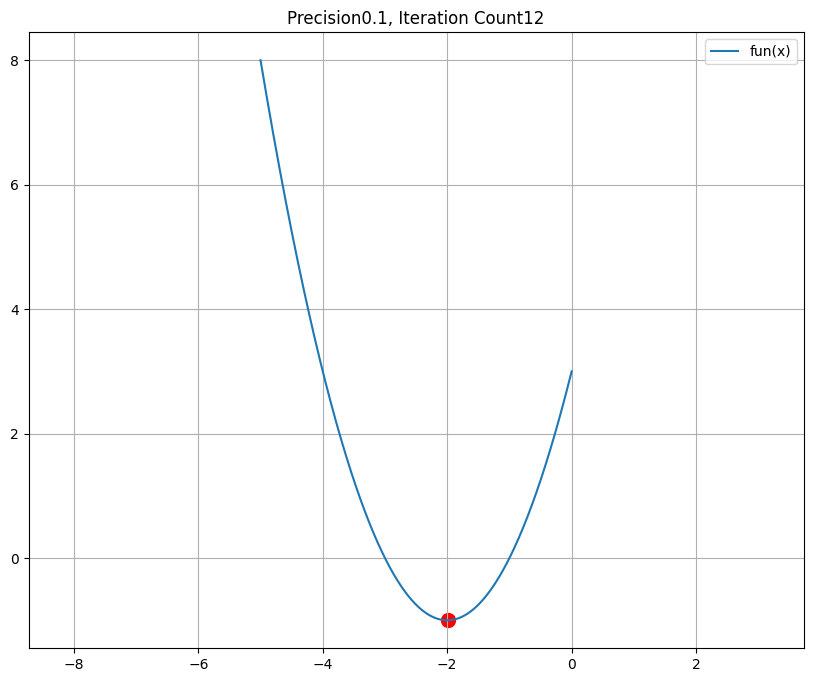

In [10]:
def interval_elimination_search(fun_input, x_min, x_max, epsilon):
    """
    区间消去法
    fun_input: 输入的函数
    x_min: 输入变量的最小值
    x_max: 输入变量的最大值
    epsilon: 精度
    返回：最小的x和y值，以及迭代次数
    """
    ruo = 0.3 - 0.1 * epsilon
    x_left_side = x_min
    x_right_side = x_max
    x_left_center = x_left_side + ruo * (x_right_side - x_left_side)
    x_right_center = x_right_side - ruo * (x_right_side - x_left_side)
    y_left_center = fun_input(x_left_center)
    y_right_center = fun_input(x_right_center)
    num = 0

    while True:
        num += 1
        if y_left_center >= y_right_center:
            x_left_side = x_left_center
            x_left_center = x_left_side + ruo * (x_right_side - x_left_side)
            x_right_center = x_right_side - ruo * (x_right_side - x_left_side)
            y_left_center = fun_input(x_left_center)
            y_right_center = fun_input(x_right_center)
        else:
            x_right_side = x_right_center
            x_left_center = x_left_side + ruo * (x_right_side - x_left_side)
            x_right_center = x_right_side - ruo * (x_right_side - x_left_side)
            y_left_center = fun_input(x_left_center)
            y_right_center = fun_input(x_right_center)

        if (x_right_side - x_left_side) <= epsilon:
            break

    min_x = (x_left_side + x_right_side) / 2
    min_y = fun_input(min_x)
    k = num
    return min_x, min_y, k

plt.rcParams.update({'font.size': 10})

x_min = -5
x_max = 0
delta_x = 1e-5
epsilon = 1e-1

x = np.arange(x_min, x_max, delta_x)
y = fun(x)

plt.figure(figsize=(10, 8))
plt.plot(x, y, label='fun(x)')

min_x, min_y, k = interval_elimination_search(fun, x_min, x_max, epsilon)

plt.scatter(min_x, min_y, color='red', s=100) 
plt.title(f'Precision{epsilon}, Iteration Count{k}')
plt.grid(True)
plt.axis('equal')
plt.legend()
plt.show()


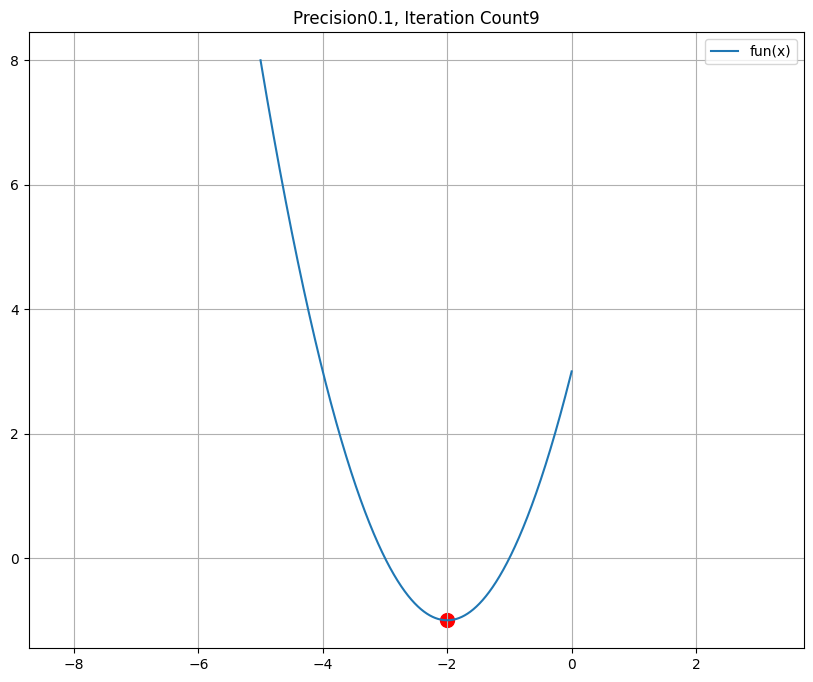

In [12]:
def golden_section_search(fun_input, x_min, x_max, epsilon):
    """
    黄金分割法
    fun_input: 输入的函数
    x_min: 输入变量的最小值
    x_max: 输入变量的最大值
    epsilon: 精度
    返回：最小的x和y值，以及迭代次数
    """
    ruo = (3 - 5**0.5) * 0.5  # 黄金比例的补数
    # 初始化
    x_left_side = x_min
    x_right_side = x_max
    x_left_center = x_left_side + ruo * (x_right_side - x_left_side)
    x_right_center = x_right_side - ruo * (x_right_side - x_left_side)
    y_left_center = fun_input(x_left_center)
    y_right_center = fun_input(x_right_center)
    
    # 初始的迭代次数
    num = 0
    
    # 循环搜索
    while True:
        num += 1
        if y_left_center >= y_right_center:
            x_left_side = x_left_center
            x_left_center = x_right_center
            x_right_center = x_right_side - ruo * (x_right_side - x_left_side)
            y_left_center = y_right_center
            y_right_center = fun_input(x_right_center)
        else:
            x_right_side = x_right_center
            x_right_center = x_left_center
            x_left_center = x_left_side + ruo * (x_right_side - x_left_side)
            y_right_center = y_left_center
            y_left_center = fun_input(x_left_center)
        
        # 判断是否满足精度要求
        if (x_right_side - x_left_side) <= epsilon:
            break
    
    # 输出的最近点和迭代的步长赋值
    min_x = (x_left_side + x_right_side) / 2
    min_y = fun_input(min_x)
    k = num
    return min_x, min_y, k

plt.rcParams.update({'font.size': 10})

x_min = -5
x_max = 0
delta_x = 1e-5
epsilon = 1e-1

x = np.arange(x_min, x_max, delta_x)
y = fun(x)

plt.figure(figsize=(10, 8))
plt.plot(x, y, label='fun(x)')

min_x, min_y, k = golden_section_search(fun, x_min, x_max, epsilon)

plt.scatter(min_x, min_y, color='red', s=100) 
plt.title(f'Precision{epsilon}, Iteration Count{k}')
plt.grid(True)
plt.axis('equal')
plt.legend()
plt.show()


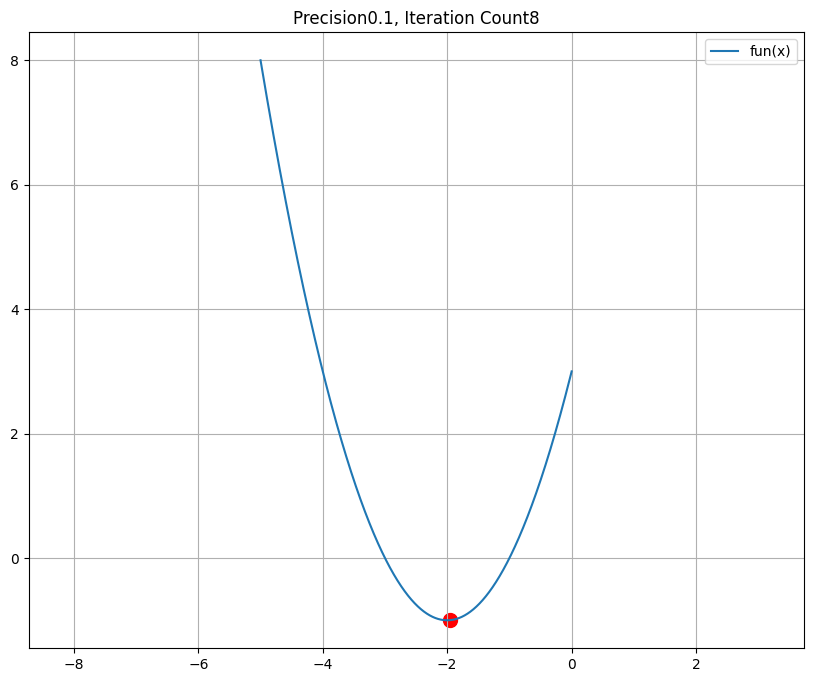

In [11]:
def fibonacci_search(fun_input, x_min, x_max, epsilon):
    """
    斐波那契法
    fun_input: 输入的函数
    x_min: 输入变量的最小值
    x_max: 输入变量的最大值
    epsilon: 精度
    返回：最小的x和y值，以及迭代次数
    """
    # 计算斐波那契数列，直到满足终止条件
    fibonacci_up = (x_max - x_min) / epsilon
    fibonacci_set = [1, 1]
    while True:
        next_fib = fibonacci_set[-1] + fibonacci_set[-2]
        if next_fib >= fibonacci_up:
            fibonacci_set.append(next_fib)
            break
        else:
            fibonacci_set.append(next_fib)

    N = len(fibonacci_set) - 1
    ruo = [1 - fibonacci_set[N - 1] / fibonacci_set[N]]
    
    x_left_side = x_min
    x_right_side = x_max
    x_left_center = x_left_side + ruo[0] * (x_right_side - x_left_side)
    x_right_center = x_right_side - ruo[0] * (x_right_side - x_left_side)
    y_left_center = fun_input(x_left_center)
    y_right_center = fun_input(x_right_center)

    for i in range(1, N):
        if N == i + 1:
            ruo.append(0.5 - 0.1 * epsilon)
        else:
            ruo.append(1 - fibonacci_set[N - i - 1] / fibonacci_set[N - i])

        if y_left_center >= y_right_center:
            x_left_side = x_left_center
            x_left_center = x_right_center
            x_right_center = x_right_side - ruo[i] * (x_right_side - x_left_side)
            y_left_center = y_right_center
            y_right_center = fun_input(x_right_center)
        else:
            x_right_side = x_right_center
            x_right_center = x_left_center
            x_left_center = x_left_side + ruo[i] * (x_right_side - x_left_side)
            y_right_center = y_left_center
            y_left_center = fun_input(x_left_center)

    min_x = (x_left_side + x_right_side) / 2
    min_y = fun_input(min_x)
    k = N - 1

    return min_x, min_y, k

plt.rcParams.update({'font.size': 10})

x_min = -5
x_max = 0
delta_x = 1e-5
epsilon = 1e-1

x = np.arange(x_min, x_max, delta_x)
y = fun(x)

plt.figure(figsize=(10, 8))
plt.plot(x, y, label='fun(x)')

min_x, min_y, k = fibonacci_search(fun, x_min, x_max, epsilon)

plt.scatter(min_x, min_y, color='red', s=100) 
plt.title(f'Precision{epsilon}, Iteration Count{k}')
plt.grid(True)
plt.axis('equal')
plt.legend()
plt.show()
